# Home assignment #5

In [1]:
import os
import cv2
import time
import math
import random
import heapq
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev

## Алгоритм A*

In [2]:
def a_star(grid, start, goal):
    height, width = grid.shape
    neighbors = [(0,1),(0,-1),(1,0),(-1,0),(1,1),(1,-1),(-1,1),(-1,-1)]

    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g = {start: 0}
    f = {start: np.linalg.norm(np.array(start)-np.array(goal))}

    visited = 0

    while open_set:
        current = heapq.heappop(open_set)[1]
        visited += 1

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            return path[::-1], visited

        for dx, dy in neighbors:
            nx, ny = current[0]+dx, current[1]+dy

            if not (0 <= nx < width and 0 <= ny < height):
                continue
            if grid[ny][nx] == 1:
                continue

            neighbor = (nx, ny)
            new_g = g[current] + np.linalg.norm([dx, dy])

            if neighbor not in g or new_g < g[neighbor]:
                came_from[neighbor] = current
                g[neighbor] = new_g
                f[neighbor] = new_g + np.linalg.norm(np.array(neighbor)-np.array(goal))
                heapq.heappush(open_set, (f[neighbor], neighbor))

    return None, visited

## Алгоритм RRT*

In [6]:
class RRTStar:
    def __init__(self, grid, start, goal):
        self.grid = grid
        self.start = start
        self.goal = goal

        self.step_size = 4
        self.max_iter = 20000
        self.search_radius = 20
        self.goal_sample_rate = 0.3

        self.nodes = [start]
        self.parent = {start: None}
        self.cost = {start: 0}

    def is_free(self, p1, p2):
        dist = int(np.linalg.norm(np.array(p1)-np.array(p2)))
        for i in range(dist+1):
            t = i / max(dist,1)
            x = int(p1[0] + t*(p2[0]-p1[0]))
            y = int(p1[1] + t*(p2[1]-p1[1]))

            if x < 0 or y < 0 or x >= self.grid.shape[1] or y >= self.grid.shape[0]:
                return False
            if self.grid[y][x] == 1:
                return False
        return True

    def nearest(self, rnd):
        return min(self.nodes, key=lambda n: np.linalg.norm(np.array(n)-np.array(rnd)))

    def steer(self, a, b):
        dx, dy = b[0]-a[0], b[1]-a[1]
        dist = math.hypot(dx, dy)
        if dist == 0:
            return a
        scale = self.step_size / dist
        return (int(a[0]+dx*scale), int(a[1]+dy*scale))

    def get_random(self):
        if random.random() < self.goal_sample_rate:
            return self.goal
        return (random.randint(0, self.grid.shape[1]-1),
                random.randint(0, self.grid.shape[0]-1))

    def plan(self):
        self.iterations = 0
        for i in range(self.max_iter):
            self.iterations += 1

            rnd = self.get_random()
            nearest = self.nearest(rnd)
            new_node = self.steer(nearest, rnd)

            if new_node in self.nodes:
                continue

            if not (0 <= new_node[0] < self.grid.shape[1] and
                    0 <= new_node[1] < self.grid.shape[0]):
                continue

            if not self.is_free(nearest, new_node):
                continue

            self.nodes.append(new_node)
            self.parent[new_node] = nearest
            self.cost[new_node] = self.cost[nearest] + np.linalg.norm(np.array(nearest)-np.array(new_node))

            for n in self.nodes:
                if n == new_node:
                    continue
                if np.linalg.norm(np.array(n)-np.array(new_node)) < self.search_radius:
                    if self.is_free(new_node, n):
                        new_cost = self.cost[new_node] + np.linalg.norm(np.array(new_node)-np.array(n))
                        if new_cost < self.cost.get(n, float('inf')):
                            self.parent[n] = new_node
                            self.cost[n] = new_cost

            if np.linalg.norm(np.array(new_node)-np.array(self.goal)) < 10:
                if self.is_free(new_node, self.goal):
                    self.parent[self.goal] = new_node
                    return self.extract_path(), self.iterations

        return None, self.iterations

    def extract_path(self):
        if self.goal not in self.parent:
            return None

        path = []
        node = self.goal
        while node is not None:
            path.append(node)
            node = self.parent.get(node)

        return path[::-1]

## Окончательное планирование пути

In [7]:
def smooth_path(path):
    if not path or len(path) < 5:
        return path
    p = np.array(path)
    try:
        tck, _ = splprep([p[:,0], p[:,1]], s=10)
        smoothed = np.array(splev(np.linspace(0,1,100), tck)).T
        return smoothed
    except:
        return path

class PathPlanningLab:
    def __init__(self, path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(path)

        res = cv2.resize(img, (200,200))
        _, thr = cv2.threshold(res, 127, 255, cv2.THRESH_BINARY)
        kernel = np.ones((3,3), np.uint8)
        self.grid = (thr == 0).astype(int)

## Анализ и Визуализация


 КАРТА: TRANQUILPATHS.PNG
Алгоритм     | Время (с)  | Длина      | Узлы/Точки
-------------------------------------------------------
A*           | 0.152      | 192.6      | 5137
RRT*         | 0.359      | FAIL       | 20000


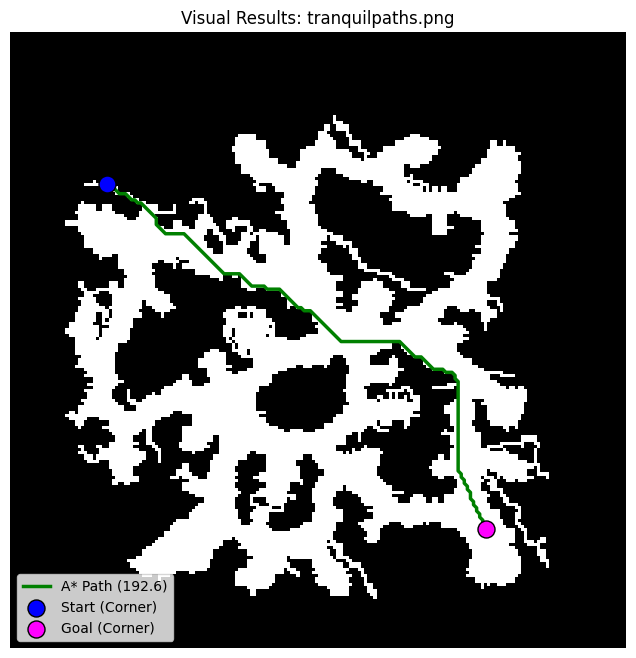


 КАРТА: DUSKWOOD.PNG
Алгоритм     | Время (с)  | Длина      | Узлы/Точки
-------------------------------------------------------
A*           | 0.302      | 215.8      | 9199
RRT*         | 3.877      | 262.8      | 2080


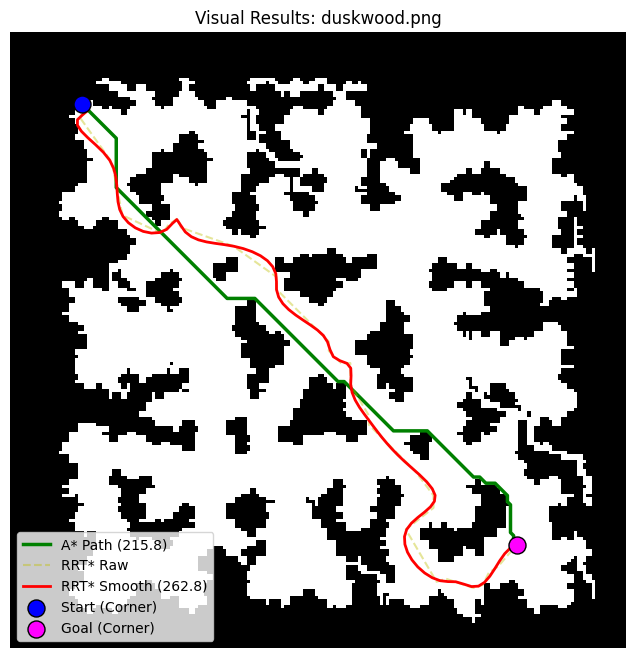


 КАРТА: GARDENOFWAR.PNG
Алгоритм     | Время (с)  | Длина      | Узлы/Точки
-------------------------------------------------------
A*           | 0.150      | 187.1      | 5133
RRT*         | 0.946      | 277.0      | 2466


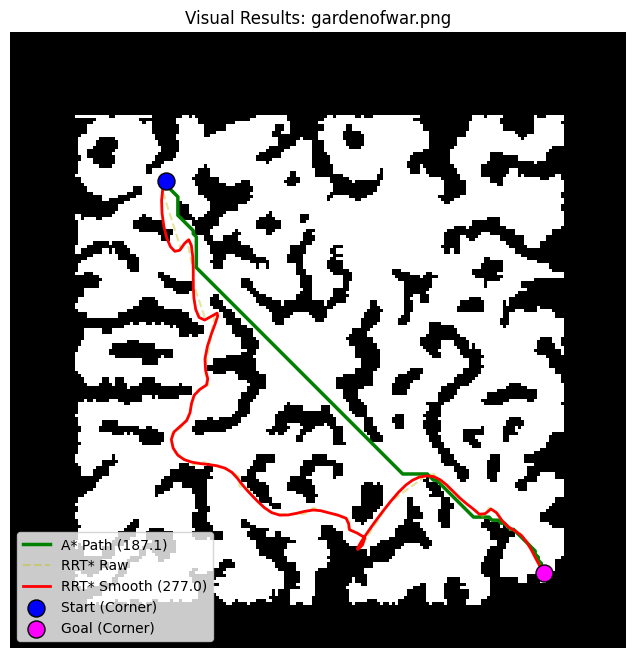


 КАРТА: STROMGUARDE.PNG
Алгоритм     | Время (с)  | Длина      | Узлы/Точки
-------------------------------------------------------
A*           | 0.000      | 5.2        | 8
RRT*         | 0.000      | 15.8       | 6


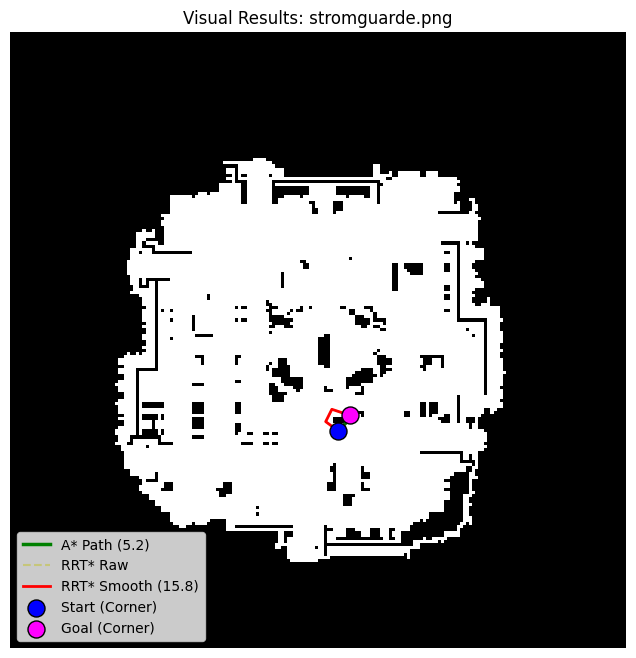


 КАРТА: THECRUCIBLE.PNG
Алгоритм     | Время (с)  | Длина      | Узлы/Точки
-------------------------------------------------------
A*           | 0.066      | 113.4      | 2253
RRT*         | 8.548      | 124.7      | 4795


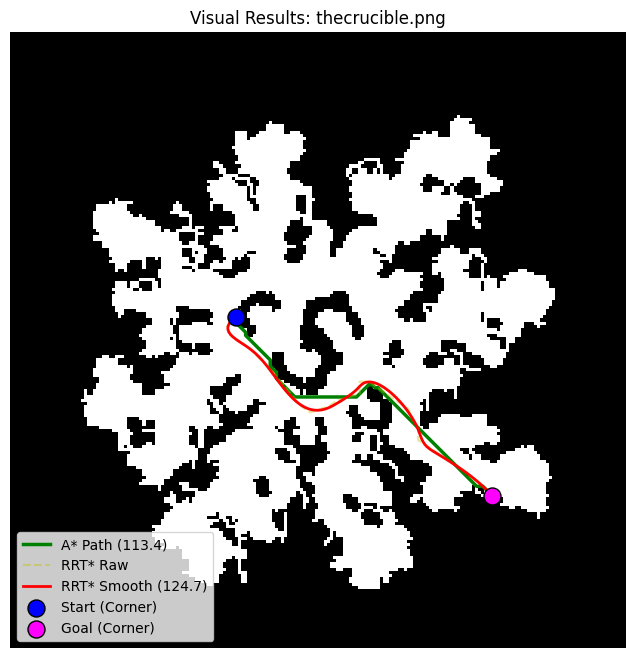

In [8]:
# Список и директория наших карт
MAPS = [
    "tranquilpaths.png",
    "duskwood.png",
    "gardenofwar.png",
    "stromguarde.png",
    "thecrucible.png"
]
LAB_DIR = r"B:\Python projects\inno\Robotics\Robotics_Course\HW5\maps"

# Рандомноищем точку
def random_free_point(grid):
    while True:
        x = random.randint(0, grid.shape[1]-1)
        y = random.randint(0, grid.shape[0]-1)
        if grid[y][x] == 0:
            return (x, y)

# Вспомогательная функция для спавна в углах
def get_corner_point(grid, mode='start'):
    h, w = grid.shape
    if mode == 'start': # Top-left
        xr, yr = (0, w // 4), (0, h // 4)
    else:
        xr, yr = (3 * w // 4, w - 1), (3 * h // 4, h - 1)
    
    for _ in range(1000):
        x = random.randint(*xr)
        y = random.randint(*yr)
        if grid[y][x] == 0:
            return (x, y)
    return random_free_point(grid)

for name in MAPS:
    lab = PathPlanningLab(os.path.join(LAB_DIR, name))

    # Генерация точек в противоположных углах
    start = get_corner_point(lab.grid, 'start')
    goal = get_corner_point(lab.grid, 'goal')

    # Расчет A*
    t0 = time.perf_counter()
    path_a, nodes_a = a_star(lab.grid, start, goal)
    t_a = time.perf_counter() - t0

    # Расчет RRT*
    t0 = time.perf_counter()
    planner = RRTStar(lab.grid, start, goal)
    path_rrt_raw, nodes_rrt = planner.plan() 
    t_r = time.perf_counter() - t0
    
    # Сглаживание
    path_smooth = smooth_path(path_rrt_raw) if path_rrt_raw else None

    # Вспомогательная функция дистанции
    def get_dist(p):
        if not p: return 0.0
        return sum(np.linalg.norm(np.array(p[j])-np.array(p[j-1])) for j in range(1, len(p)))

    # Выводим статистику по картам
    print(f"\n{'='*60}")
    print(f" КАРТА: {name.upper()}")
    print(f"{'='*60}")
    print(f"{'Алгоритм':<12} | {'Время (с)':<10} | {'Длина':<10} | {'Узлы/Точки'}")
    print(f"{'-'*55}")
    print(f"{'A*':<12} | {t_a:<10.3f} | {get_dist(path_a):<10.1f} | {nodes_a}")
    
    rrt_len = f"{get_dist(path_rrt_raw):.1f}" if path_rrt_raw else "FAIL"
    print(f"{'RRT*':<12} | {t_r:<10.3f} | {rrt_len:<10} | {nodes_rrt}")

    # Отрисовка карт
    plt.figure(figsize=(8, 8))
    plt.imshow(1 - lab.grid, cmap='gray')
    
    if path_a:
        plt.plot(*zip(*path_a), 'g-', label=f'A* Path ({get_dist(path_a):.1f})', linewidth=2.5)
    
    if path_rrt_raw:
        plt.plot(*zip(*path_rrt_raw), 'y--', alpha=0.4, label='RRT* Raw')
        if path_smooth is not None:
            plt.plot(*zip(*path_smooth), 'r-', label=f'RRT* Smooth ({get_dist(path_rrt_raw):.1f})', linewidth=2)
    
    plt.scatter(*start, c='blue', s=150, edgecolors='black', label='Start (Corner)', zorder=5)
    plt.scatter(*goal, c='magenta', s=150, edgecolors='black', label='Goal (Corner)', zorder=5)
    
    plt.title(f"Visual Results: {name}")
    plt.legend(loc='lower left')
    plt.axis('off')
    plt.show()

Как мы видим на первой карте, алгоритму RRT очень сложнонайти путь из узкого начало, поэтому алгоритм фейлится, тогда как A* работает стабильно.